# Exercício 3 — Preparando dados reais para uma rede neural

Pré-processamento do [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)
(`train.csv`, o único arquivo rotulado) para uma rede com `tanh` nas camadas
escondidas. A regra que rege o notebook inteiro: **toda estatística é calculada só no
treino** — o teste apenas recebe as transformações.

Seed fixa: `random_state = 42` no split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

SEED = 42

# identidade visual dos meus gráficos: paleta fixa + eixos limpos
CORES = ["#E8A13D", "#C75146", "#6B8F3D", "#33658A"]  # âmbar, telha, oliva, aço
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=CORES),
    "figure.dpi": 110,
})

df = pd.read_csv("spaceship-titanic/train.csv")
print("shape bruto:", df.shape)
df.head()

shape bruto: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## A — Conhecer os dados

Cada linha é um passageiro da nave; a coluna-alvo `Transported` diz se ele foi
transportado para outra dimensão na colisão com a anomalia espaço-temporal. Ou seja:
**classificação binária**.

In [2]:
print(df["Transported"].value_counts().to_string())
print(f"\nProporção da classe positiva (True): {df['Transported'].mean():.4f}")

Transported
True     4378
False    4315

Proporção da classe positiva (True): 0.5036


**Balanço de classes:** 4378 `True` × 4315 `False` — **50.36%** de positivos nas
8693 amostras. Praticamente empatado, o que me poupa de qualquer malabarismo com
desbalanceamento.

**Features** (fora os identificadores `PassengerId`, `Name` e `Cabin`, que eu
descarto):

| Tipo | Colunas |
|---|---|
| Numéricas | `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` |
| Categóricas | `HomePlanet`, `CryoSleep`, `Destination`, `VIP` |

In [3]:
GASTOS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUMERICAS = ["Age"] + GASTOS
CATEGORICAS = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

# Tabela de valores faltantes por coluna
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "%": (df.isna().mean() * 100).round(2),
}).sort_values("faltantes", ascending=False)
faltantes

,faltantes,%
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


Todas as colunas de entrada têm entre **179 e 217** buracos (**2.06% a 2.50%** cada);
só `PassengerId` e `Transported` vêm completas.

In [4]:
# Estatísticas das colunas de gasto (só descrição — nada é ajustado aqui)
df[GASTOS].agg(["mean", "median", "max"]).round(2)

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
mean,224.69,458.08,173.73,311.14,304.85
median,0.00,0.00,0.00,0.00,0.00
max,14327.00,29813.00,23492.00,22408.00,24133.00


**Média × mediana.** A mediana das cinco colunas de gasto é **0** — mais da metade
dos passageiros não gastou um centavo — enquanto as médias vão de 173.73
(`ShoppingMall`) a 458.08 (`FoodCourt`) e os máximos chegam a 29813. Média muito
acima da mediana é a assinatura clássica de **cauda pesada à direita**: uma minoria
gastadora puxa a média para cima e domina a dispersão.

## B — Separar antes de transformar

In [5]:
X = df.drop(columns=["Transported", "Cabin", "Name", "PassengerId"])
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train = X_train.copy()
X_test = X_test.copy()
print(f"treino: {X_train.shape} | teste: {X_test.shape}")
print(f"proporção True — treino: {y_train.mean():.4f} | teste: {y_test.mean():.4f}")

treino: (6954, 10) | teste: (1739, 10)
proporção True — treino: 0.5036 | teste: 0.5037


Split **80/20 estratificado** pelo alvo com seed fixa: 6954 no treino, 1739 no teste,
os dois com 50.4% de positivos.

**Por que separar antes?** O teste existe para simular dado que o modelo nunca viu.
Se eu calculasse qualquer estatística (mediana, mínimo/máximo, categorias) com o
dataset inteiro, informação do teste vazaria para dentro do pré-processamento e a
avaliação viraria maquiagem (*data leakage*). Então daqui para baixo: estatística sai
**só do treino**, e o teste apenas recebe a transformação pronta.

## C — Pré-processar

In [6]:
# --- Valores faltantes: mediana nas numéricas, moda nas categóricas (só do treino) ---
medianas = X_train[NUMERICAS].median()
modas = X_train[CATEGORICAS].mode().iloc[0]

X_train[NUMERICAS] = X_train[NUMERICAS].fillna(medianas)
X_test[NUMERICAS] = X_test[NUMERICAS].fillna(medianas)
X_train[CATEGORICAS] = X_train[CATEGORICAS].fillna(modas)
X_test[CATEGORICAS] = X_test[CATEGORICAS].fillna(modas)

print("medianas (treino):", medianas.to_dict())
print("modas (treino):   ", modas.to_dict())

medianas (treino): {'Age': 27.0, 'RoomService': 0.0, 'FoodCourt': 0.0, 'ShoppingMall': 0.0, 'Spa': 0.0, 'VRDeck': 0.0}
modas (treino):    {'HomePlanet': 'Earth', 'CryoSleep': False, 'Destination': 'TRAPPIST-1e', 'VIP': False}


**Por quê assim:** nas numéricas, a **mediana** é imune às caudas pesadas do item A
(a média seria puxada pelos gastões) — na prática ela imputa `Age = 27` e gasto `0`,
o valor típico. Nas categóricas, a **moda** preenche com a categoria mais comum sem
inventar níveis novos.

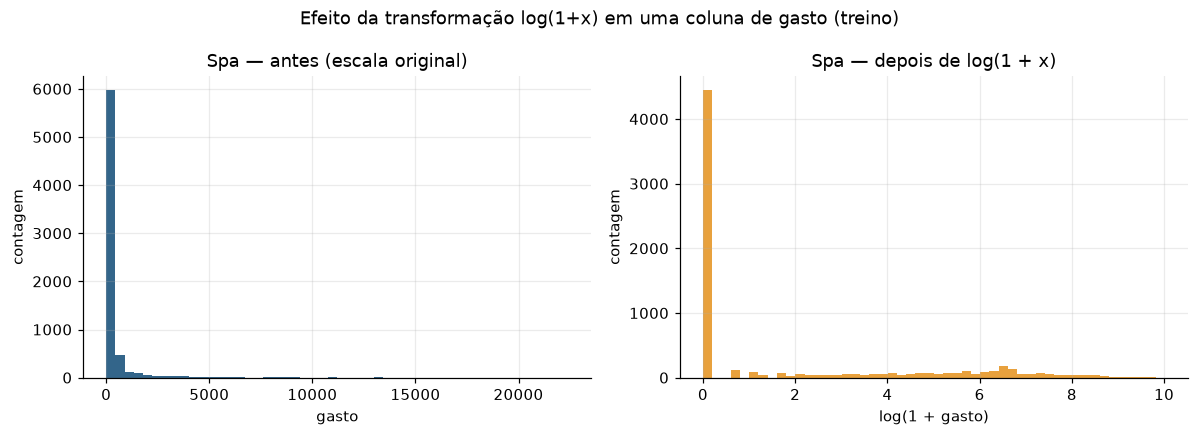

In [7]:
# --- Feature engineering: TotalSpend (depois da imputação, senão a soma vira NaN) ---
X_train["TotalSpend"] = X_train[GASTOS].sum(axis=1)
X_test["TotalSpend"] = X_test[GASTOS].sum(axis=1)

# --- Caudas pesadas: log(1 + x) nos gastos e no TotalSpend ---
COLS_LOG = GASTOS + ["TotalSpend"]
spa_antes = X_train["Spa"].copy()  # guardo para o histograma
X_train[COLS_LOG] = np.log1p(X_train[COLS_LOG])
X_test[COLS_LOG] = np.log1p(X_test[COLS_LOG])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(spa_antes, bins=50, color=CORES[3])
axes[0].set_title("Spa — antes (escala original)")
axes[0].set_xlabel("gasto")
axes[1].hist(X_train["Spa"], bins=50, color=CORES[0])
axes[1].set_title("Spa — depois de log(1 + x)")
axes[1].set_xlabel("log(1 + gasto)")
for ax in axes:
    ax.set_ylabel("contagem")
fig.suptitle("Efeito da transformação log(1+x) em uma coluna de gasto (treino)")
plt.tight_layout()
plt.show()

**Por que o log importa para o `tanh`:** sem ele, os máximos na casa das dezenas de
milhares mandam na escala — depois de normalizar, quase todo mundo fica espremido num
intervalinho perto de $-1$ e os extremos caem onde o `tanh` satura (derivada ≈ 0).
Ali o gradiente morre de vez. O `log(1+x)` comprime a cauda, espalha a massa de dados
pela faixa útil da ativação e ainda mantém `0 → 0`.

In [8]:
# --- Categóricas: one-hot (ajustado só no treino) ---
codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
codificador.fit(X_train[CATEGORICAS])
onehot_treino = codificador.transform(X_train[CATEGORICAS])
onehot_teste = codificador.transform(X_test[CATEGORICAS])
print("categorias aprendidas no treino:")
for col, cats in zip(CATEGORICAS, codificador.categories_):
    print(f"  {col}: {list(cats)}")

categorias aprendidas no treino:
  HomePlanet: ['Earth', 'Europa', 'Mars']
  CryoSleep: [False, True]
  Destination: ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
  VIP: [False, True]


**E se aparecer uma categoria só no teste?** Com `handle_unknown="ignore"`, um nível
que o treino nunca viu vira um **vetor todo-zeros** naquele grupo de colunas — o
pipeline não quebra e o teste não cria coluna nova. (Aqui as categorias coincidem
entre treino e teste, mas a garantia vale em geral.)

In [9]:
# --- Escala: normalização para [-1, 1] nas numéricas, na mão (min/max só do treino) ---
NUM_FINAIS = NUMERICAS + ["TotalSpend"]
minimos = X_train[NUM_FINAIS].min()
maximos = X_train[NUM_FINAIS].max()

num_treino = 2 * (X_train[NUM_FINAIS] - minimos) / (maximos - minimos) - 1
num_teste = 2 * (X_test[NUM_FINAIS] - minimos) / (maximos - minimos) - 1

# matriz final = numéricas escaladas + one-hot (que já vive em {0, 1} ⊂ [-1, 1])
nomes_features = NUM_FINAIS + list(codificador.get_feature_names_out(CATEGORICAS))
X_train_final = np.hstack([num_treino.to_numpy(), onehot_treino])
X_test_final = np.hstack([num_teste.to_numpy(), onehot_teste])

print(f"treino — min: {X_train_final.min():.4f} | max: {X_train_final.max():.4f}")
print(f"teste  — min: {X_test_final.min():.4f} | max: {X_test_final.max():.4f}")

treino — min: -1.0000 | max: 1.0000
teste  — min: -1.0000 | max: 1.1383


**A escolha da escala.** Normalização para $[-1, 1]$, a faixa nativa do `tanh` — e
fiz na mão de propósito: min e max vêm **do treino**, a fórmula é
$2(x - \min)/(\max - \min) - 1$. No treino o resultado é exatamente
$[-1.0000,\ 1.0000]$. No teste o máximo chega a **1.1383** (`ShoppingMall` e
`VRDeck` têm valores acima do máximo visto no treino) — e isso não é bug: é a
consequência esperada de ajustar a escala só no treino, ou seja, evidência de que não
houve vazamento. O leve estouro não incomoda o `tanh`, que aceita qualquer real.

## D — Verificar e visualizar

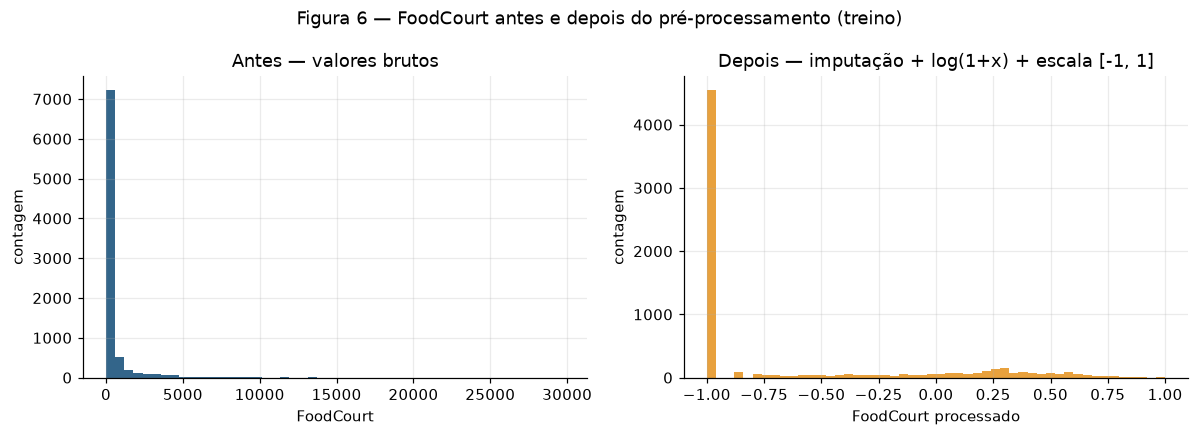

In [10]:
# Figura 6 — FoodCourt antes (bruto) e depois (pipeline completo)
idx_fc = nomes_features.index("FoodCourt")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["FoodCourt"].dropna(), bins=50, color=CORES[3])
axes[0].set_title("Antes — valores brutos")
axes[0].set_xlabel("FoodCourt")
axes[1].hist(X_train_final[:, idx_fc], bins=50, color=CORES[0])
axes[1].set_title("Depois — imputação + log(1+x) + escala [-1, 1]")
axes[1].set_xlabel("FoodCourt processado")
for ax in axes:
    ax.set_ylabel("contagem")
fig.suptitle("Figura 6 — FoodCourt antes e depois do pré-processamento (treino)")
plt.tight_layout()
plt.show()

In [11]:
# Checagens finais, explícitas
print(f"NaN restantes — treino: {np.isnan(X_train_final).sum()} | "
      f"teste: {np.isnan(X_test_final).sum()}")
print(f"shape final — treino: {X_train_final.shape} | teste: {X_test_final.shape}")
print(f"faixa de valores — treino: [{X_train_final.min():.4f}, {X_train_final.max():.4f}] | "
      f"teste: [{X_test_final.min():.4f}, {X_test_final.max():.4f}]")
fc_bruto = df.loc[X_train.index, "FoodCourt"]  # FoodCourt do treino, antes de transformar
print(f"média/mediana de FoodCourt no treino ANTES de transformar: "
      f"{fc_bruto.mean():.2f} / {fc_bruto.median():.2f}")

NaN restantes — treino: 0 | teste: 0
shape final — treino: (6954, 17) | teste: (1739, 17)
faixa de valores — treino: [-1.0000, 1.0000] | teste: [-1.0000, 1.1383]
média/mediana de FoodCourt no treino ANTES de transformar: 452.61 / 0.00


**Checagens:** zero `NaN`; matriz final de treino com shape **(6954, 17)**
(7 numéricas, contando o `TotalSpend`, + 10 colunas one-hot); valores em
$[-1.0000, 1.0000]$ no treino e $[-1.0000, 1.1383]$ no teste — tudo em casa para o
`tanh`.

**Reflexão.** Se eu tivesse que apostar em qual decisão mais afeta o treinamento, é o
**`log(1+x)` nos gastos**. Sem ele, a normalização seria ditada pelos máximos
extremos (até 29813) e mais de metade dos dados ficaria espremida num intervalo
minúsculo colado em $-1$ — justamente a região onde o `tanh` satura e o gradiente
some. As outras escolhas (mediana × média, one-hot, escala) mexem pouco na geometria;
o log muda o que a rede consegue enxergar.

---

> **O que eu tiro daqui:** pré-processar é decidir a geometria que a rede recebe — no
> caso do `tanh`, caudas comprimidas e entradas em $[-1, 1]$. E ajustar tudo só no
> treino é o que mantém o número confiável: o teste estourar de leve a faixa da
> escala é o comportamento *esperado* de um pipeline sem vazamento.